# Customer Churn Prediction & Business Intelligence: Telecom

**Business problem.** A telecom provider loses customers every month. Which customers are most likely to leave, why, and how much revenue would be protected by contacting the highest-risk group with a retention offer?

**What this notebook does**
1. Explores the data with **SQL** (SQLite) and pandas.
2. Builds an end-to-end machine learning pipeline: cleaning, encoding, scaling, and model comparison.
3. Corrects class imbalance with **SMOTE** (applied inside cross-validation so no test data leaks into training).
4. Tunes **XGBoost** with 5-fold cross-validation and compares it with Logistic Regression and Random Forest baselines.
5. Explains the model with **SHAP** to find the main churn drivers.
6. Quantifies the revenue at stake in the **top 20% highest-risk customers** and exports files for a **Tableau** dashboard.

**Dataset.** IBM Telco Customer Churn sample dataset: 7,043 customers, 20 features, one target (`Churn`). Source: <https://github.com/IBM/telco-customer-churn-on-icp4d> (Apache-2.0 repository). It is a sample dataset, not real company data.

> Run order: The cells are executed from top to bottom. Every random step uses `random_state=42`, so results are repeatable.

## 1. Setup

In [11]:
import warnings, sqlite3, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score, classification_report,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold, cross_validate, cross_val_predict,
                                     train_test_split)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import loguniform, randint, uniform
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
DATA_PATH = Path("data/Telco-Customer-Churn.csv")
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
OUT, FIG, TAB = Path("outputs"), Path("outputs/figures"), Path("outputs/tableau")
for folder in (DATA_PATH.parent, FIG, TAB):
    folder.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():    
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
print("Data file:", DATA_PATH)

Data file: data/Telco-Customer-Churn.csv


## 2. Load and audit the data


In [13]:
raw = pd.read_csv(DATA_PATH)
print("Rows, columns:", raw.shape)
print("Duplicate customer IDs:", raw["customerID"].duplicated().sum())
print("\nColumn types:\n", raw.dtypes.to_string())
raw.head()

Rows, columns: (7043, 21)
Duplicate customer IDs: 0

Column types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# TotalCharges is stored as text because 11 rows contain a blank space instead of a number. Which customers are they?
blank = raw["TotalCharges"].str.strip() == ""
print("Blank TotalCharges rows:", blank.sum())
print("Their tenure values:", raw.loc[blank, "tenure"].unique())

Blank TotalCharges rows: 11
Their tenure values: [0]


All 11 blank values belong to customers with `tenure = 0`, meaning brand-new customers who have not been billed yet. A total of 0 is therefore the correct value, so we fill them with 0 instead of dropping the rows.

## 3. Explore with SQL
Analysts often start in SQL, so we load the table into an in-memory SQLite database and answer the first business questions with queries.

In [17]:
conn = sqlite3.connect(":memory:")
raw.to_sql("customers", conn, index=False, if_exists="replace")

def sql(query):
    return pd.read_sql_query(query, conn)

sql("""
SELECT COUNT(*)                                        AS customers,
       SUM(Churn = 'Yes')                              AS churned,
       ROUND(100.0 * SUM(Churn = 'Yes') / COUNT(*), 1) AS churn_rate_pct
FROM customers
""")

,customers,churned,churn_rate_pct
0,7043,1869,26.5


In [18]:
# Churn rate by contract type
sql("""
SELECT Contract,
       COUNT(*)                                        AS customers,
       ROUND(100.0 * SUM(Churn = 'Yes') / COUNT(*), 1) AS churn_rate_pct,
       ROUND(AVG(MonthlyCharges), 2)                   AS avg_monthly_charges
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC
""")

,Contract,customers,churn_rate_pct,avg_monthly_charges
0,Month-to-month,3875,42.7,66.40
1,One year,1473,11.3,65.05
2,Two year,1695,2.8,60.77


In [19]:
# Churn rate by how long the customer has been with the company
sql("""
SELECT CASE WHEN tenure <= 12 THEN '1) 0-12 months'
            WHEN tenure <= 24 THEN '2) 13-24 months'
            WHEN tenure <= 48 THEN '3) 25-48 months'
            ELSE                   '4) 49+ months' END AS tenure_band,
       COUNT(*)                                        AS customers,
       ROUND(100.0 * SUM(Churn = 'Yes') / COUNT(*), 1) AS churn_rate_pct
FROM customers
GROUP BY tenure_band
ORDER BY tenure_band
""")

,tenure_band,customers,churn_rate_pct
0,1) 0-12 months,2186,47.4
1,2) 13-24 months,1024,28.7
2,3) 25-48 months,1594,20.4
3,4) 49+ months,2239,9.5


In [20]:
# Monthly revenue lost from customers who churned, by internet service
sql("""
SELECT InternetService,
       SUM(Churn = 'Yes')                                            AS churned_customers,
       ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges END), 0) AS monthly_revenue_lost
FROM customers
GROUP BY InternetService
ORDER BY monthly_revenue_lost DESC
""")

,InternetService,churned_customers,monthly_revenue_lost
0,Fiber optic,1297,114300.0
1,DSL,459,22529.0
2,No,113,2302.0


## 4. Clean the data

In [22]:
df = raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)      # new customers: 0 billed so far
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})                     # treat as a Yes/No category
y = (df["Churn"] == "Yes").astype(int)                                                 # 1 = churned
X = df.drop(columns=["customerID", "Churn"])

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print(f"{len(numeric_cols)} numeric and {len(categorical_cols)} categorical features")
print(f"Churn rate: {y.mean():.1%}  ->  imbalanced target ({y.sum()} churners vs {(1 - y).sum()} stayers)")

3 numeric and 16 categorical features
Churn rate: 26.5%  ->  imbalanced target (1869 churners vs 5174 stayers)


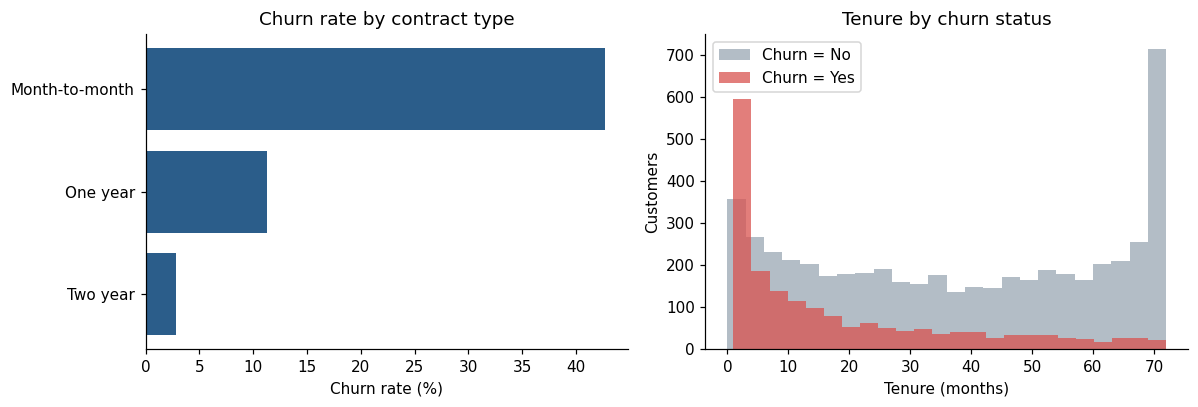

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
rate = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
ax[0].barh(rate.index, rate.values, color="#2b5d8a")
ax[0].set_xlabel("Churn rate (%)"); ax[0].set_title("Churn rate by contract type")
for name, colour in (("No", "#9aa7b4"), ("Yes", "#d9534f")):
    ax[1].hist(df.loc[df["Churn"] == name, "tenure"], bins=24, alpha=.75, label=f"Churn = {name}", color=colour)
ax[1].set_xlabel("Tenure (months)"); ax[1].set_ylabel("Customers"); ax[1].set_title("Tenure by churn status"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG / "01_eda_contract_tenure.png", bbox_inches="tight"); plt.show()

## 5. Train/test split and preprocessing
We keep 20% of customers aside as a **hold-out test set** that is never used for tuning. The split is *stratified* so both sets keep the same churn rate.

The preprocessor scales numeric columns (so no feature dominates only because of its units) and one-hot encodes categories (turns each category into its own 0/1 column). It sits **inside** the model pipeline, so every cross-validation fold learns its scaling from its own training data only.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} churn) | Test: {len(X_test)} rows ({y_test.mean():.1%} churn)")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 5634 rows (26.5% churn) | Test: 1409 rows (26.5% churn)


## 6. Baseline models, with and without SMOTE
**Why SMOTE?** Only about 1 in 4 customers churns, so a model can look accurate while missing many churners. SMOTE (Synthetic Minority Over-sampling Technique) creates new synthetic churner examples during training so the model pays more attention to them.

**The safe way to use it:** SMOTE must only touch the training part of each cross-validation fold. Using `imblearn`'s `Pipeline` guarantees that, and the validation folds always stay untouched and realistic.

We compare three models, each with and without SMOTE, using 5-fold stratified cross-validation on the training set. **ROC AUC** measures how well the model ranks churners above stayers, **recall** is the share of real churners we catch, and **precision** is the share of flagged customers who really churn.

In [27]:
scoring = {"roc_auc": "roc_auc", "recall": "recall", "precision": "precision", "f1": "f1"}

base_models = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=3000),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": lambda: XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, eval_metric="logloss",
                                     random_state=RANDOM_STATE, n_jobs=1),
}

def build_pipeline(estimator, use_smote):
    steps = [("pre", preprocess)]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("clf", estimator))
    return ImbPipeline(steps)

rows = []
for name, make in base_models.items():
    for use_smote in (False, True):
        result = cross_validate(build_pipeline(make(), use_smote), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({"model": name, "smote": use_smote,
                     "cv_roc_auc": result["test_roc_auc"].mean(), "cv_recall": result["test_recall"].mean(),
                     "cv_precision": result["test_precision"].mean(), "cv_f1": result["test_f1"].mean()})
baseline = pd.DataFrame(rows)
baseline.round(3)

,model,smote,cv_roc_auc,cv_recall,cv_precision,cv_f1
0,Logistic Regression,False,0.846,0.544,0.652,0.592
1,Logistic Regression,True,0.845,0.789,0.527,0.631
2,Random Forest,False,0.821,0.483,0.633,0.547
3,Random Forest,True,0.819,0.558,0.592,0.574
4,XGBoost,False,0.845,0.515,0.649,0.574
5,XGBoost,True,0.843,0.631,0.605,0.617


In [28]:
# Did SMOTE help the minority class (churners)?
pivot = baseline.pivot(index="model", columns="smote", values=["cv_recall", "cv_roc_auc"])
summary = pd.DataFrame({
    "recall_without_smote": pivot[("cv_recall", False)], "recall_with_smote": pivot[("cv_recall", True)],
    "auc_without_smote": pivot[("cv_roc_auc", False)], "auc_with_smote": pivot[("cv_roc_auc", True)],
})
summary["recall_gain"] = summary["recall_with_smote"] - summary["recall_without_smote"]
summary.round(3)

,recall_without_smote,recall_with_smote,auc_without_smote,auc_with_smote,recall_gain
model,,,,,
Logistic Regression,0.544,0.789,0.846,0.845,0.245
Random Forest,0.483,0.558,0.821,0.819,0.075
XGBoost,0.515,0.631,0.845,0.843,0.116


SMOTE raises **recall** for every model (more churners are caught) at the cost of some precision, while ROC AUC barely moves. That is the expected trade-off: SMOTE changes *where the decision threshold effectively sits*, not the model's underlying ability to rank customers. Because the business goal is finding churners before they leave, we keep SMOTE in the final pipeline.

## 7. Tune the models with cross-validation
We search random combinations of hyperparameters (the settings of a model) for each of the three models, scoring every combination with 5-fold cross-validated ROC AUC. Tuning uses **only the training set**, so the hold-out test set stays a fair, untouched exam.

In [31]:
searches = {
    "XGBoost": (build_pipeline(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1), True), {
        "clf__n_estimators": randint(150, 500), "clf__max_depth": randint(2, 6),
        "clf__learning_rate": loguniform(0.01, 0.2), "clf__subsample": uniform(0.6, 0.4),
        "clf__colsample_bytree": uniform(0.5, 0.5), "clf__min_child_weight": randint(1, 10),
        "clf__reg_lambda": loguniform(0.5, 20)}, 40),
    "Logistic Regression": (build_pipeline(LogisticRegression(max_iter=3000), True),
                            {"clf__C": loguniform(0.01, 10)}, 15),
    "Random Forest": (build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1), True), {
        "clf__n_estimators": randint(200, 600), "clf__max_depth": [6, 8, 10, 12, None],
        "clf__min_samples_leaf": randint(1, 15)}, 15),
}

tuned = {}
for name, (pipeline, space, n_iter) in searches.items():
    search = RandomizedSearchCV(pipeline, space, n_iter=n_iter, scoring="roc_auc", cv=cv,
                                random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    tuned[name] = search
    print(f"{name:20s} best cross-validated ROC AUC = {search.best_score_:.4f}")

print("\nBest XGBoost settings:")
for key, value in tuned["XGBoost"].best_params_.items():
    print(f"  {key.replace('clf__', ''):18s} {value:.4g}" if isinstance(value, float) else f"  {key.replace('clf__', ''):18s} {value}")

XGBoost              best cross-validated ROC AUC = 0.8479
Logistic Regression  best cross-validated ROC AUC = 0.8449
Random Forest        best cross-validated ROC AUC = 0.8444

Best XGBoost settings:
  colsample_bytree   0.55
  learning_rate      0.03958
  max_depth          2
  min_child_weight   4
  n_estimators       301
  reg_lambda         5.517
  subsample          0.6226


## 8. Final evaluation on the hold-out test set
This is the number to trust: the models have never seen these customers. We also bootstrap the test set (resample it 1,000 times) to see how uncertain each AUC is, because differences of a few thousandths between models may just be noise.

In [33]:
rng = np.random.default_rng(RANDOM_STATE)
holdout_rows, proba_store = [], {}
for name, search in tuned.items():
    proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    proba_store[name] = proba
    pred = (proba >= 0.5).astype(int)
    boot = []
    for _ in range(1000):
        idx = rng.integers(0, len(y_test), len(y_test))
        if y_test.iloc[idx].nunique() == 2:
            boot.append(roc_auc_score(y_test.iloc[idx], proba[idx]))
    holdout_rows.append({"model": name, "cv_roc_auc": search.best_score_, "test_roc_auc": roc_auc_score(y_test, proba),
                         "auc_95ci_low": np.percentile(boot, 2.5), "auc_95ci_high": np.percentile(boot, 97.5),
                         "test_pr_auc": average_precision_score(y_test, proba), "recall": recall_score(y_test, pred),
                         "precision": precision_score(y_test, pred), "f1": f1_score(y_test, pred)})
holdout = pd.DataFrame(holdout_rows).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
holdout.round(3)

,model,cv_roc_auc,test_roc_auc,auc_95ci_low,auc_95ci_high,test_pr_auc,recall,precision,f1
0,XGBoost,0.848,0.843,0.820,0.864,0.649,0.741,0.552,0.632
1,Random Forest,0.844,0.840,0.817,0.861,0.636,0.754,0.543,0.632
2,Logistic Regression,0.845,0.839,0.815,0.861,0.625,0.794,0.502,0.615


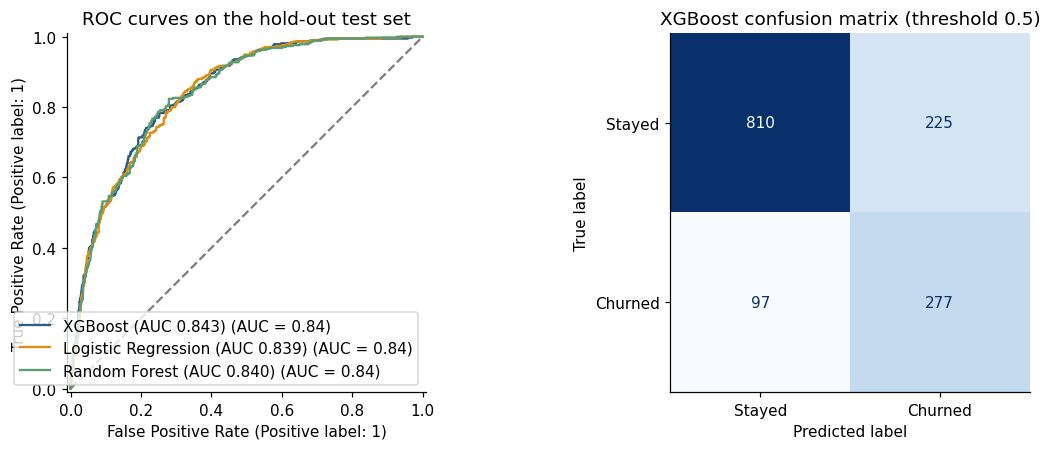

              precision    recall  f1-score   support

      Stayed       0.89      0.78      0.83      1035
     Churned       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [34]:
best_name = "XGBoost"   # chosen because it has the highest cross-validated AUC of the tuned models
best_pipeline = tuned[best_name].best_estimator_
proba_best = proba_store[best_name]
pred_best = (proba_best >= 0.5).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, colour in (("XGBoost", "#2b5d8a"), ("Logistic Regression", "#e08e0b"), ("Random Forest", "#5a9e6f")):
    RocCurveDisplay.from_predictions(y_test, proba_store[name], name=f"{name} (AUC {roc_auc_score(y_test, proba_store[name]):.3f})",
                                     ax=ax[0], color=colour)
ax[0].plot([0, 1], [0, 1], "--", color="grey"); ax[0].set_title("ROC curves on the hold-out test set")
ConfusionMatrixDisplay.from_predictions(y_test, pred_best, display_labels=["Stayed", "Churned"], cmap="Blues", ax=ax[1], colorbar=False)
ax[1].set_title("XGBoost confusion matrix (threshold 0.5)")
plt.tight_layout(); plt.savefig(FIG / "02_roc_confusion.png", bbox_inches="tight"); plt.show()
print(classification_report(y_test, pred_best, target_names=["Stayed", "Churned"]))

## 9. Explain the model with SHAP
A model that only outputs a score is hard to act on. **SHAP** (SHapley Additive exPlanations) shows how much each feature pushed each customer's churn prediction up or down. A positive SHAP value means the feature raised that customer's churn risk.

One-hot encoding splits a single column such as `Contract` into several 0/1 columns. To answer "which *original* features matter most?" we add the SHAP values of the pieces back together for each customer before averaging.

In [36]:
xgb_fitted = best_pipeline.named_steps["clf"]
X_test_encoded = best_pipeline.named_steps["pre"].transform(X_test)
encoded_names = [n.split("__", 1)[1] for n in best_pipeline.named_steps["pre"].get_feature_names_out()]

explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_test_encoded)          # one SHAP value per customer per encoded feature

def original_feature(encoded_name):
    for col in categorical_cols:
        if encoded_name.startswith(col + "_"):
            return col
    return encoded_name                                        # numeric features keep their own name

groups = pd.Series([original_feature(n) for n in encoded_names])
grouped = pd.DataFrame({g: shap_values[:, (groups == g).values].sum(axis=1) for g in groups.unique()})
importance = grouped.abs().mean().sort_values(ascending=False).rename("mean_abs_shap").to_frame()
importance["share_of_total"] = importance["mean_abs_shap"] / importance["mean_abs_shap"].sum()
importance.head(10).round(3)

,mean_abs_shap,share_of_total
Contract,0.725,0.231
tenure,0.434,0.139
InternetService,0.289,0.092
OnlineSecurity,0.257,0.082
PaymentMethod,0.251,0.080
TechSupport,0.175,0.056
PaperlessBilling,0.170,0.054
MonthlyCharges,0.129,0.041
MultipleLines,0.124,0.039
Dependents,0.116,0.037


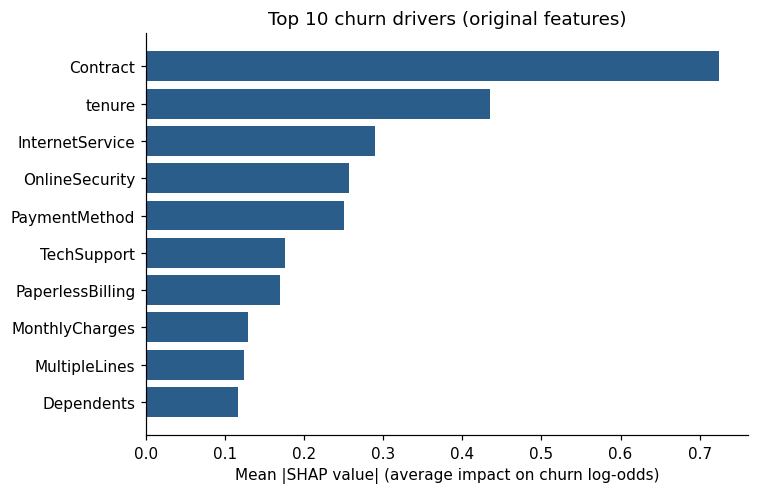

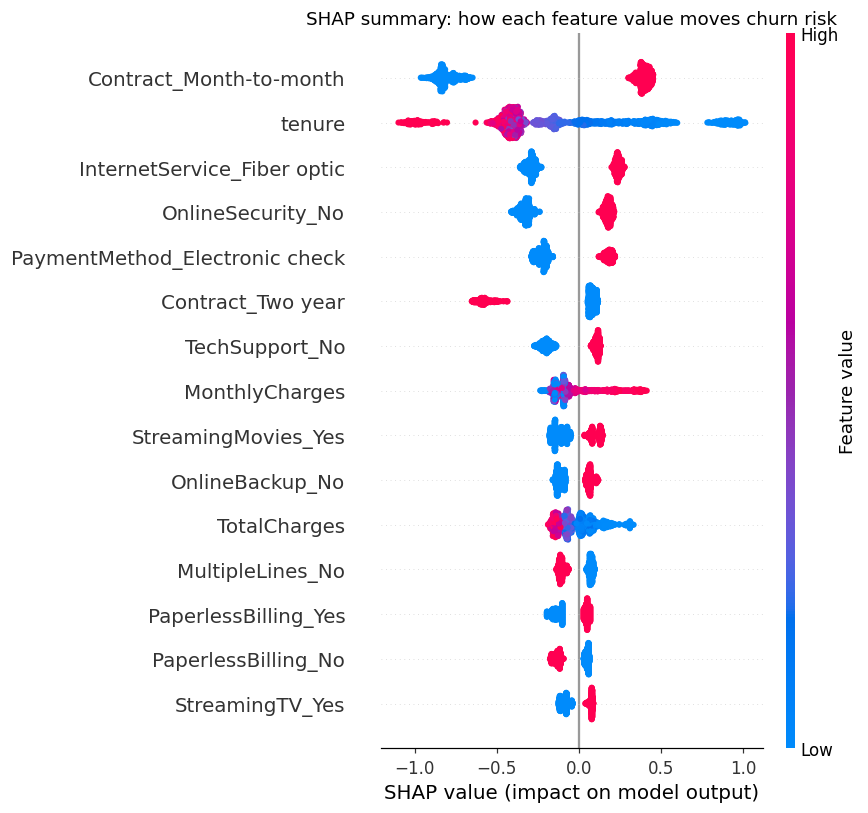

Three primary churn drivers: ['Contract', 'tenure', 'InternetService']


In [37]:
fig, ax = plt.subplots(figsize=(7, 4.6))
top = importance.head(10).iloc[::-1]
ax.barh(top.index, top["mean_abs_shap"], color="#2b5d8a")
ax.set_xlabel("Mean |SHAP value| (average impact on churn log-odds)"); ax.set_title("Top 10 churn drivers (original features)")
plt.tight_layout(); plt.savefig(FIG / "03_shap_top_drivers.png", bbox_inches="tight"); plt.show()

shap.summary_plot(shap_values, X_test_encoded, feature_names=encoded_names, max_display=15, show=False)
plt.title("SHAP summary: how each feature value moves churn risk"); plt.tight_layout()
plt.savefig(FIG / "04_shap_beeswarm.png", bbox_inches="tight"); plt.show()

top3 = importance.head(3).index.tolist()
print("Three primary churn drivers:", top3)

How to read the beeswarm plot: each dot is one customer. Dots to the right raised that customer's churn risk. Colour shows the feature value (red = high, blue = low). For example, red dots on the right for `MonthlyCharges` mean high monthly bills push churn risk up.

## 10. Business impact: the top 20% highest-risk customers
To score **every** customer fairly, we use *out-of-fold* predictions: the tuned XGBoost pipeline is trained on four fifths of the customers and predicts the remaining fifth, five times, so no customer is scored by a model that trained on them.

We rank customers by predicted churn probability and study the top 20%, which is the group a retention team could realistically contact.

In [40]:
oof_proba = cross_val_predict(clone(best_pipeline), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                              method="predict_proba", n_jobs=-1)[:, 1]

scored = df[["customerID", "Contract", "InternetService", "PaymentMethod", "tenure", "MonthlyCharges", "Churn"]].copy()
scored["churn_probability"] = oof_proba
scored["churned"] = y.values
scored["annual_revenue"] = scored["MonthlyCharges"] * 12
scored["risk_rank"] = scored["churn_probability"].rank(ascending=False, method="first")
scored["risk_decile"] = pd.qcut(scored["risk_rank"], 10, labels=list(range(1, 11))).astype(int)   # decile 1 = highest risk
scored["top_20pct"] = scored["risk_rank"] <= 0.20 * len(scored)

top_group = scored[scored["top_20pct"]]
total_churners = scored["churned"].sum()
captured = top_group["churned"].sum()
base_rate = scored["churned"].mean()
precision_top = top_group["churned"].mean()

print(f"Top 20% = {len(top_group):,} customers")
print(f"Churn rate inside the top 20%: {precision_top:.1%}  (overall base rate {base_rate:.1%}, lift {precision_top / base_rate:.2f}x)")
print(f"Churners captured: {captured:,} of {total_churners:,} = {captured / total_churners:.1%}  (random targeting would capture 20.0%)")

Top 20% = 1,408 customers
Churn rate inside the top 20%: 67.1%  (overall base rate 26.5%, lift 2.53x)
Churners captured: 945 of 1,869 = 50.6%  (random targeting would capture 20.0%)


In [41]:
decile = scored.groupby("risk_decile").agg(customers=("churned", "size"), churners=("churned", "sum"),
                                           churn_rate=("churned", "mean"), avg_probability=("churn_probability", "mean"))
decile["annual_revenue_at_risk"] = scored[scored["churned"] == 1].groupby("risk_decile")["annual_revenue"].sum()
decile["cumulative_churners_captured"] = decile["churners"].cumsum() / total_churners
decile.round(3)

,customers,churners,churn_rate,avg_probability,annual_revenue_at_risk,cumulative_churners_captured
risk_decile,,,,,,
1,705,529,0.750,0.854,507258.6,0.283
2,704,416,0.591,0.738,379768.8,0.506
3,704,307,0.436,0.613,270323.4,0.670
4,704,233,0.331,0.488,195299.4,0.795
5,705,152,0.216,0.357,130834.8,0.876
6,704,117,0.166,0.236,96864.6,0.938
7,704,60,0.085,0.133,47424.6,0.971
8,704,36,0.051,0.071,29669.4,0.990
9,704,9,0.013,0.035,6385.8,0.995


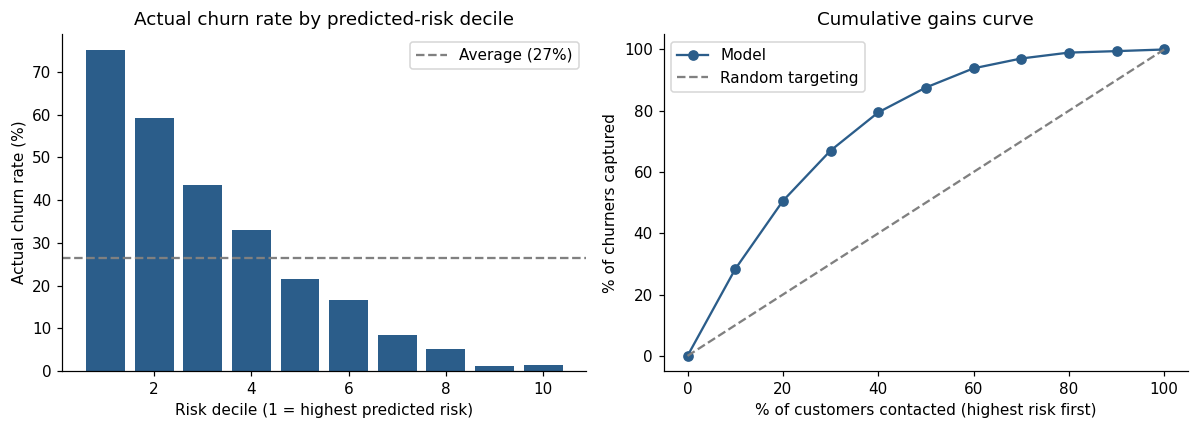

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(decile.index, decile["churn_rate"] * 100, color="#2b5d8a")
ax[0].axhline(base_rate * 100, color="grey", ls="--", label=f"Average ({base_rate:.0%})")
ax[0].set_xlabel("Risk decile (1 = highest predicted risk)"); ax[0].set_ylabel("Actual churn rate (%)")
ax[0].set_title("Actual churn rate by predicted-risk decile"); ax[0].legend()
ax[1].plot([0] + list(decile.index * 10), [0] + list(decile["cumulative_churners_captured"] * 100), marker="o", color="#2b5d8a", label="Model")
ax[1].plot([0, 100], [0, 100], "--", color="grey", label="Random targeting")
ax[1].set_xlabel("% of customers contacted (highest risk first)"); ax[1].set_ylabel("% of churners captured")
ax[1].set_title("Cumulative gains curve"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG / "05_deciles_gains.png", bbox_inches="tight"); plt.show()

### Revenue at stake
Two kinds of numbers follow, and it is important not to mix them up:

* **Observed facts in this dataset:** how much annual revenue (monthly charge x 12) the churners inside the top 20% represent.
* **A scenario built on assumptions:** how much of that revenue a retention campaign might protect. The success rate and cost per contact below are **assumptions you can change**, not results from the data. In practice you would measure them with a pilot campaign.

In [44]:
revenue_at_risk_top = top_group.loc[top_group["churned"] == 1, "annual_revenue"].sum()
revenue_at_risk_all = scored.loc[scored["churned"] == 1, "annual_revenue"].sum()
random_expected = 0.20 * revenue_at_risk_all
print(f"Annual revenue of ALL churners:                    {revenue_at_risk_all:>12,.0f}")
print(f"Annual revenue of churners inside the top 20%:     {revenue_at_risk_top:>12,.0f}  ({revenue_at_risk_top / revenue_at_risk_all:.1%} of the total)")
print(f"Expected if the same number of customers were picked at random: {random_expected:>10,.0f}")

# ---- Scenario assumptions (change these) ----
SUCCESS_RATE = 0.30        # share of contacted would-be churners that a retention offer keeps
COST_PER_CONTACT = 20      # cost of one retention contact/offer, in the dataset's currency units

def scenario(success, cost):
    saved = success * revenue_at_risk_top
    spend = cost * len(top_group)
    return saved, spend, saved - spend

saved, spend, net = scenario(SUCCESS_RATE, COST_PER_CONTACT)
print(f"\nScenario ({SUCCESS_RATE:.0%} save rate, {COST_PER_CONTACT} per contact): revenue protected {saved:,.0f}, campaign cost {spend:,.0f}, net {net:,.0f}")

grid = pd.DataFrame([{"save_rate": s, "cost_per_contact": c, "revenue_protected": scenario(s, c)[0],
                      "campaign_cost": scenario(s, c)[1], "net_benefit": scenario(s, c)[2]}
                     for s in (0.10, 0.20, 0.30, 0.40) for c in (10, 20, 40)])
grid.pivot(index="save_rate", columns="cost_per_contact", values="net_benefit").round(0)

Annual revenue of ALL churners:                       1,669,570
Annual revenue of churners inside the top 20%:          887,027  (53.1% of the total)
Expected if the same number of customers were picked at random:    333,914

Scenario (30% save rate, 20 per contact): revenue protected 266,108, campaign cost 28,160, net 237,948


cost_per_contact,10,20,40
save_rate,,,
0.1,74623.0,60543.0,32383.0
0.2,163325.0,149245.0,121085.0
0.3,252028.0,237948.0,209788.0
0.4,340731.0,326651.0,298491.0


## 11. Export files for the Tableau dashboard
Tableau reads flat files, so we save the scored customers and summary tables as CSVs. Suggested worksheets are listed in the README (KPI cards, risk decile chart, revenue at risk by contract, SHAP driver bars, and a filterable customer list).

In [46]:
scored.drop(columns=["risk_rank"]).round(4).to_csv(TAB / "customer_risk_scores.csv", index=False)
decile.reset_index().round(4).to_csv(TAB / "decile_summary.csv", index=False)
importance.reset_index(names="feature").round(4).to_csv(TAB / "shap_feature_importance.csv", index=False)
holdout.round(4).to_csv(TAB / "model_comparison.csv", index=False)
grid.round(2).to_csv(TAB / "revenue_scenarios.csv", index=False)
baseline.round(4).to_csv(OUT / "baseline_cv_results.csv", index=False)
print(sorted(p.name for p in TAB.iterdir()))

['customer_risk_scores.csv', 'decile_summary.csv', 'model_comparison.csv', 'revenue_scenarios.csv', 'shap_feature_importance.csv']


## 12. Conclusions and retention strategy

*The figures below come from the run saved in this notebook (random_state = 42).*

**Model performance.** The tuned XGBoost model reaches a **hold-out ROC AUC of 0.843** (bootstrap 95% interval about 0.82 to 0.87) and a cross-validated AUC of 0.848. Logistic Regression and Random Forest land within about 0.003 of it, and the intervals overlap, so the honest reading is that the three models perform similarly. XGBoost was chosen for the highest cross-validated score and for explaining well with SHAP. SMOTE raised the share of churners caught (cross-validated recall for XGBoost rose from 0.52 to 0.63) without changing AUC.

**What drives churn.** SHAP ranks **contract type, tenure and internet service** as the three biggest drivers, followed by online security, payment method and tech support. The raw data agrees: month-to-month customers churn at 42.7% versus 2.8% on two-year contracts, customers in their first year churn at 47.4% versus 9.5% after four years, and fibre optic customers account for about 82% of the monthly revenue lost to churn. Among internet customers, those without online security or tech support churn at roughly 42% versus about 15% for those who have them.

**Who to contact.** The top 20% of customers by predicted risk (1,408 people) churned at 67.2%, which is **2.5 times the average**, and this group contains **50.6% of all churners**. Every one of them is on a month-to-month contract, their average tenure is about 9 months (against 32 for all customers), and 82% have fibre optic internet. Their churners represent **about 889,000 in annual revenue, 53% of the total churn revenue**, against roughly 334,000 if the same number of customers were picked at random. In the illustrative scenario (30% of contacted churners retained, 20 per contact), the campaign protects about 267,000 in annual revenue for a cost of about 28,000. Those two inputs are assumptions, not findings, and the sensitivity table shows how the result changes.

**Suggested retention actions (to test, not to assume)**
1. Offer month-to-month customers in their first year an incentive to move to a one- or two-year contract.
2. Bundle online security and tech support for fibre customers, since customers without them churn far more often.
3. Nudge electronic-check payers (45% churn) towards automatic payment methods (about 15 to 17%).
4. Run a small controlled pilot on the top-risk group, with a comparison group that receives no offer, to measure the real save rate before scaling up.


## 13. Limitations
* **Sample data.** The IBM dataset is a teaching sample. Real churn work would use actual billing, usage and support data.
* **Small differences between models.** The tuned models score within a few thousandths of AUC of each other, and the bootstrap intervals overlap. XGBoost was chosen for having the best cross-validated score and for working well with SHAP, but a regularised Logistic Regression is nearly as good and simpler to explain.
* **SMOTE on one-hot columns.** Standard SMOTE interpolates between customers as if the 0/1 columns were continuous. `SMOTENC` treats categorical features properly and is a sensible next experiment.
* **Snapshot data.** There is no time dimension, so we cannot test how the model performs on customers from a later period.
* **SHAP shows association, not cause.** A driver such as month-to-month contracts is a signal for targeting, not proof that changing the contract would stop churn. A controlled retention pilot would show that.
* **Revenue scenario.** The save rate and contact cost are assumptions, and revenue is not the same as profit.